In [ ]:
pip install shap; optuna


[I 2025-05-25 16:20:02,968] A new study created in memory with name: no-name-0ed82296-f264-49e9-bb2a-3dadba6a0fe0
[I 2025-05-25 16:21:21,170] Trial 0 finished with value: 0.32260795935647757 and parameters: {'n_estimators': 277, 'max_depth': 24, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.32260795935647757.
[I 2025-05-25 16:21:52,975] Trial 1 finished with value: 0.13121080559575493 and parameters: {'n_estimators': 105, 'max_depth': 28, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.32260795935647757.
[I 2025-05-25 16:22:42,565] Trial 2 finished with value: 0.35489160138458736 and parameters: {'n_estimators': 282, 'max_depth': 11, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 'sqrt'}. Best is trial 2 with value: 0.35489160138458736.
[I 2025-05-25 16:23:05,425] Trial 3 finished with value: 0.39747807017543857 and parameters: {'n_estimators': 105, 'max_depth':


=== Asthma Test Metrics ===
ROC AUC: 0.828 | PR AUC: 0.533
Accuracy: 0.870
Precision: 0.970
Recall: 0.033
F1: 0.064
              precision    recall  f1-score   support

         0.0       0.87      1.00      0.93     12481
         1.0       0.97      0.03      0.06      1936

    accuracy                           0.87     14417
   macro avg       0.92      0.52      0.50     14417
weighted avg       0.88      0.87      0.81     14417



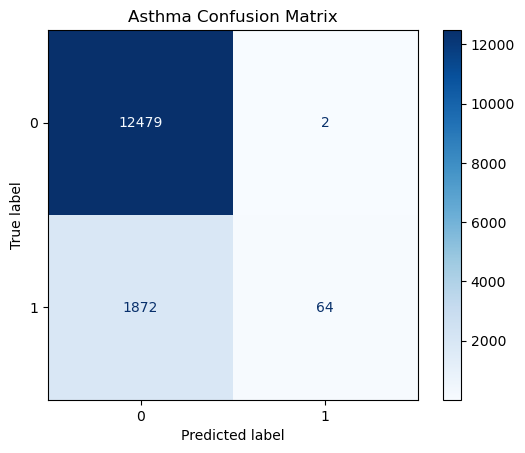

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 640x480 with 0 Axes>

In [6]:
# ASTHMA PREDICTION WITH OPTUNA

import pandas as pd
import numpy as np
import optuna
import shap
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, roc_auc_score, precision_recall_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)

# Load and prepare data
df = pd.read_csv("../filtered_data_v1.3.csv")
df = df.drop(columns=["Unnamed: 0", "Unnamed: 0.1", "SEQN_new", "DIQ010", "MCQ160B", "MCQ160C", "MCQ160E"])

X = df.drop(columns=["MCQ010"])
y = df['MCQ010'].apply(lambda x: 2 if x >= 5 else x).replace({2: 0})  # Optional: convert to 0/1 if needed
#X = X.apply(pd.to_numeric, errors="coerce").fillna(0)

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# Optuna objective
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 400),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': 'balanced',
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    score = f1_score(preds, y_val)
    return score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# Train best model
best_model = RandomForestClassifier(**study.best_params)
best_model.fit(X_train, y_train)
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Metrics
roc_auc = roc_auc_score(y_test, y_test_proba)
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = auc(recall, precision)

print("\n=== Asthma Test Metrics ===")
print(f"ROC AUC: {roc_auc:.3f} | PR AUC: {pr_auc:.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.3f}")
print(f"F1: {f1_score(y_test, y_test_pred):.3f}")
print(classification_report(y_test, y_test_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Asthma Confusion Matrix")
plt.show()

# SHAP
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values[1], X_test, show=True)
